# Indian male: close versus two tighter framings

## tl;dr

Using the exact prior `close-seed-50.mp4` as baseline, both tighter videos retain strong mouth-motion agreement. The 1.50× clip is closest to baseline timing (**0.920 zero-lag correlation**) while rendering the face at about **200 px wide**, versus 133 px baseline. Visual review finds clearer mouth detail at 1.50×, with the tradeoff that the top of the hair/head can be cropped during motion. The 1.25× clip is the safer composition balance.


## Context & Methods

The exact previously committed Indian-male close clip is reused as the 1.00× baseline. New 1.25× and 1.50× references are center-zoomed from the same source. Audio, seed 50, 320×576 profile, four steps, model settings, and 10-second duration remain fixed.

**GPU provenance:** NVIDIA GeForce RTX 4070 SUPER, 12,282 MiB visible VRAM; driver 595.84; measured 2026-09-16. Exact evidence is in `evidence-indian-male-closer-20260916/results.json`.

### Key Assumptions

- Agreement with the existing close output measures motion stability, not phoneme correctness.
- Visual clarity and crop tradeoffs are based on matched-frame review, not a blinded preference study.


## Data

Sources: the exact prior close clip plus two new generated clips. Each contains 250 frames at 25 FPS; MediaPipe detects the face in every frame.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

evidence = Path('evidence-indian-male-closer-20260916')
run = json.loads((evidence / 'results.json').read_text())
motion = json.loads((evidence / 'mouth-motion.json').read_text())
rows = pd.DataFrame([{k: v for k, v in row.items() if k != 'opening_series'} for row in motion['rows']])
comparisons = pd.DataFrame([{k: v for k, v in row.items() if k != 'lag_scan_frames'} for row in motion['comparisons']])
assert run['status'] == 'complete' and len(run['rows']) == 2
assert len(rows) == 3 and (rows['frames'] == 250).all() and (rows['detection_rate'] == 1).all()
rows

,label,path,frames,detected,detection_rate,mean_face_width_px,mean_eye_span_px,mean_opening,p95_opening,opening_sd,mean_abs_frame_change
0,close-100,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,133.293010,86.704043,0.105361,0.237665,0.067114,0.022749
1,closer-125,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,167.566375,108.812119,0.100889,0.275883,0.075081,0.024013
2,closest-150,benchmarks/distance_lipsync/evidence-indian-ma...,250,250,1.0,199.625003,130.150454,0.092752,0.233452,0.063618,0.022669


## Results

In [2]:
order = ['close-100', 'closer-125', 'closest-150']
summary = rows.set_index('label').reindex(order)
for metric in ['mean_opening', 'p95_opening', 'mean_abs_frame_change']:
    summary[f'{metric}_change_vs_close_pct'] = (summary[metric] / summary.loc['close-100', metric] - 1) * 100
summary[['mean_face_width_px', 'mean_opening', 'p95_opening', 'mean_abs_frame_change',
         'mean_opening_change_vs_close_pct', 'p95_opening_change_vs_close_pct',
         'mean_abs_frame_change_change_vs_close_pct']].round(4)

,mean_face_width_px,mean_opening,p95_opening,mean_abs_frame_change,mean_opening_change_vs_close_pct,p95_opening_change_vs_close_pct,mean_abs_frame_change_change_vs_close_pct
label,,,,,,,
close-100,133.2930,0.1054,0.2377,0.0227,0.0000,0.0000,0.0000
closer-125,167.5664,0.1009,0.2759,0.0240,-4.2446,16.0808,5.5580
closest-150,199.6250,0.0928,0.2335,0.0227,-11.9679,-1.7728,-0.3517


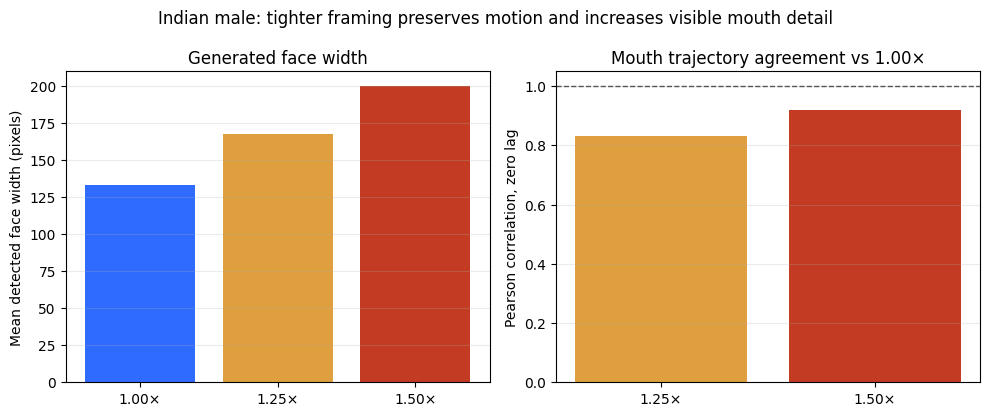

In [3]:
colors = ['#2F6BFF', '#E09F3E', '#C23B22']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(['1.00×', '1.25×', '1.50×'], summary['mean_face_width_px'], color=colors)
axes[0].set_title('Generated face width')
axes[0].set_ylabel('Mean detected face width (pixels)')
axes[0].grid(axis='y', alpha=.25)

corr = comparisons.set_index('label').reindex(['closer-125', 'closest-150'])
axes[1].bar(['1.25×', '1.50×'], corr['zero_lag_correlation_vs_close'], color=colors[1:])
axes[1].axhline(1, color='#555', lw=1, ls='--')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Mouth trajectory agreement vs 1.00×')
axes[1].set_ylabel('Pearson correlation, zero lag')
axes[1].grid(axis='y', alpha=.25)
fig.suptitle('Indian male: tighter framing preserves motion and increases visible mouth detail')
fig.tight_layout()
fig.savefig(evidence / 'closer-distance-effect.png', dpi=160, bbox_inches='tight')
plt.show()

The 1.50× output is the most temporally similar to the baseline and increases detected face width by roughly 50%. Its average normalized opening is 12.0% lower, but p95 opening and frame-to-frame movement remain within about 2% and 1% of baseline respectively. The 1.25× clip has a 16.1% higher p95 opening and a small one-frame best-fit phase difference.

## Takeaways

1. **Closer continues to work well; there is no articulation collapse.** Both new framings preserve full face tracking and strong motion agreement.
2. **1.50× provides the clearest mouth view and most stable timing relative to baseline.** Zero-lag correlation is 0.920 with no phase adjustment.
3. **1.25× is the safer general framing recommendation.** It improves visible face/mouth size without the hair/head cropping seen at 1.50×.
4. These results support a practical preferred range around **168–200 px face width on a 320 px canvas**, subject to the desired amount of headroom.
5. This is one seed and one utterance. The result establishes a useful composition test, not a universal lip-sync-accuracy threshold.
